In [10]:
# Anomaly_Detection_on_Graphs / notebooks / 02_feature_engineering.ipynb
# Purpose: 從原始 CSV 建構圖、工程特徵、準備 GNN 輸入 (x, edge_index, y)

import pandas as pd
import networkx as nx
import torch
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
#from google.colab import drive
#drive.mount('/content/drive')

In [12]:
# =====================================
# 1. 路徑設定（Colab 專用）
# =====================================
#DATA_ROOT = "/content/drive/MyDrive/data/raw/"   # google drive 中的資料路徑
DATA_ROOT = "../data/raw/"   # 本地資料路徑

CLASSES_PATH = DATA_ROOT + "elliptic_txs_classes.csv"
EDGES_PATH   = DATA_ROOT + "elliptic_txs_edgelist.csv"
FEATS_PATH   = DATA_ROOT + "elliptic_txs_features.csv"

In [13]:
# =====================================
# 2. 載入數據（你已成功，可直接用）
# =====================================
df_classes = pd.read_csv(CLASSES_PATH)
df_edges   = pd.read_csv(EDGES_PATH)
df_feats   = pd.read_csv(FEATS_PATH, header=None) # no header in features file, so set header=None, pandas will auto-assign column names as integers starting from 0

df_feats.columns = ['txId'] + [f'feat_{i}' for i in range(1, 167)]

print("載入完成，形狀確認：")
print("classes:", df_classes.shape)
print("edges  :", df_edges.shape)
print("feats  :", df_feats.shape)

載入完成，形狀確認：
classes: (203769, 2)
edges  : (234355, 2)
feats  : (203769, 167)


In [14]:
# =====================================
# 3. 過濾標記 & 映射標籤
# =====================================
df_classes = df_classes[df_classes['class'] != 'unknown'].copy() # 只保留 '1' 和 '2' 的行，並創建副本以避免 SettingWithCopyWarning
df_classes['label'] = df_classes['class'].map({'1': 1, '2': 0}) # 這裡將 '1' 映射為 1（異常），'2' 映射為 0（正常）

df_classes.set_index('txId', inplace=True) # 將 'txId' 設置為索引，方便後續根據節點 ID 查找標籤
df_feats.set_index('txId', inplace=True)   # 注意：這裡用 'txId' 而非 0

print("\n標記數據分布：")
print(df_classes['label'].value_counts(normalize=True))


標記數據分布：
label
0    0.902392
1    0.097608
Name: proportion, dtype: float64



建圖完成：
節點數: 203,769
邊數  : 234,355


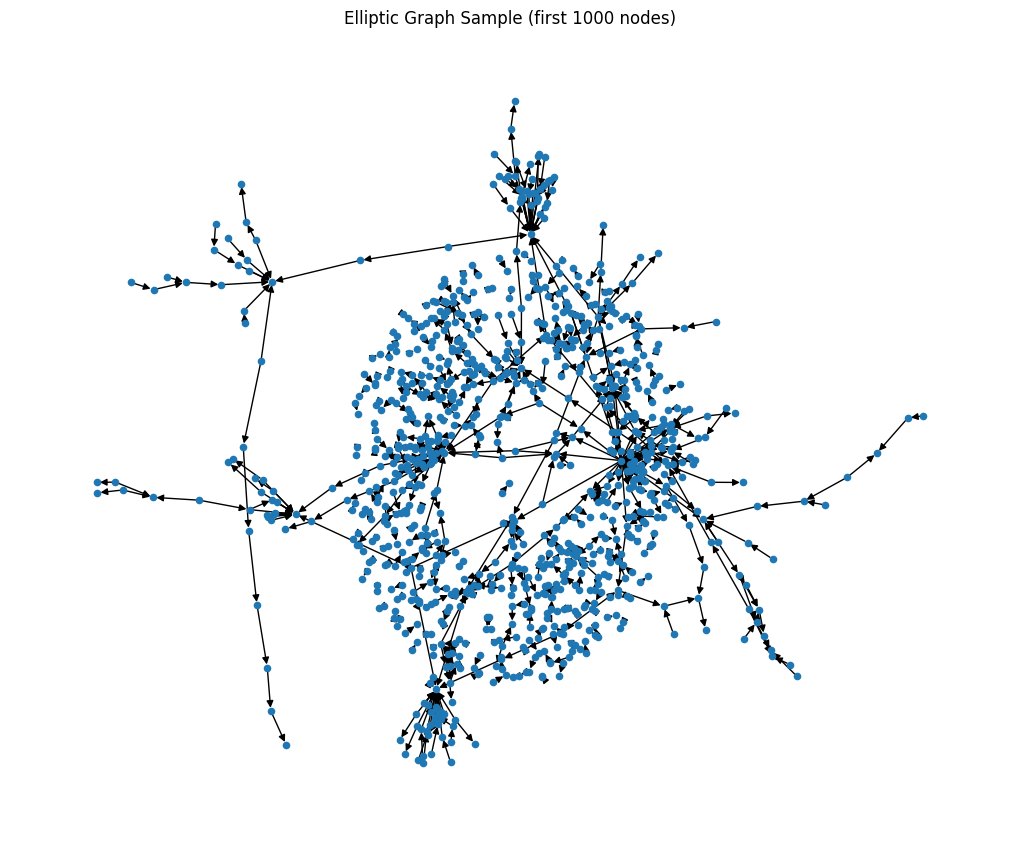

In [15]:
# =====================================
# 4. 建構有向圖
# =====================================
G = nx.from_pandas_edgelist(df_edges, 'txId1', 'txId2', create_using=nx.DiGraph())

# 只保留有特徵的節點
nodes_with_feats = set(df_feats.index) & set(G.nodes()) # 取交集，確保圖中只保留那些在特徵表中有對應行的節點, turn to set for faster lookup and then take intersection with G.nodes() to get the nodes that are present in both the graph and the features dataframe
G = G.subgraph(nodes_with_feats).copy() # 注意：subgraph 會返回一個 view，使用 copy() 來創建一個獨立的圖，避免後續修改影響原圖

print(f"\n建圖完成：")
print(f"節點數: {G.number_of_nodes():,}")   # 使用千分位逗號格式化輸出
print(f"邊數  : {G.number_of_edges():,}")

# 可視化小樣本（前1000節點，避免太大畫不出）
sub_G = G.subgraph(list(G.nodes())[:1000]) # 取前1000個節點的子圖
pos = nx.spring_layout(sub_G)  # spring layout for better visualization, connected nodes will be closer together, unconnected nodes will be farther apart
plt.figure(figsize=(10,8))      #   set figure size for 10inch horizontal and 8inch vertical
nx.draw(sub_G, pos, node_size=20, arrows=True)  # node_size=20, arrows=True shows the direction of edges
plt.title("Elliptic Graph Sample (first 1000 nodes)")
plt.show()

In [ ]:
# =====================================
# 5. 轉換成 GNN 格式
# =====================================
nodes = list(G.nodes()) # 確保節點順序與特徵表對齊, guarantee the order of nodes is consistent with the features dataframe, we will use this list to index both edge_index and x
node_to_idx = {node: i for i, node in enumerate(nodes)} # 建立節點 ID 到索引的映射，方便後續構建 edge_index 和對齊特徵
num_nodes = len(nodes) # 節點數量，後續用於初始化張量

# edge_index [2, E]
edge_list = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]    # 將圖中的邊轉換為索引對列表(數字)，使用 node_to_idx 映射將節點 ID 轉換為對應的索引, list of (source, target) pairs
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous() # edge_index 用.t()由 [E, 2] 轉置成 [2, E] 的形狀，並使用 contiguous() 確保內存連續性

# x [N, 166] 初始特徵 
x = torch.tensor(df_feats.loc[nodes].values, dtype=torch.float)  # 這裡使用 df_feats.loc[nodes] 來確保特徵的順序與圖中的節點順序一致，並且轉換為 PyTorch 張量

# y [N]，無標記為 -1
y = torch.full([num_nodes], -1, dtype=torch.long)   # 初始化所有節點的標籤為 -1，表示無標記
for node in nodes:
    if node in df_classes.index:
        y[node_to_idx[node]] = df_classes.loc[node, 'label']  # 如果該節點在標記表(nodes)中，則將對應位置的標籤更新為 0 或 1

print(f"\nGNN 輸入準備完成：")
print(f"x 形狀: {x.shape}")
print(f"edge_index 形狀: {edge_index.shape}")
print(f"y 形狀: {y.shape}")
print(f"有標記比例: {(y != -1).float().mean():.4f}")  # 計算有標記的節點比例，y != -1 會返回一個布爾張量，表示哪些節點有標記，然後轉換為 float 並取平均值得到比例


GNN 輸入準備完成：
x 形狀: torch.Size([203769, 166])
edge_index 形狀: torch.Size([2, 234355])
y 形狀: torch.Size([203769])
有標記比例: 0.2285


In [ ]:
# =====================================
# 6. 特徵工程：加 PageRank
# =====================================
pr = nx.pagerank(G, alpha=0.85) # PageRank 是一個字典，key 是節點 ID，value 是對應的 PageRank 分數
pr_tensor = torch.tensor([pr.get(n, 0.0) for n in nodes], dtype=torch.float).unsqueeze(1)   # 將 PageRank 分數轉換為張量，並使用 unsqueeze(1) 來增加一個維度，使其形狀由 [N] 變為 [N, 1]
x = torch.cat([x, pr_tensor], dim=1) # 將 PageRank 特徵與原始特徵拼接在一起，dim=1 表示在特徵維度上拼接, concatenate on columns (features)

print(f"加 PageRank 後 x 形狀: {x.shape}")

# 你可以繼續加其他特徵，例如：
# degree = torch.tensor([G.degree(n) for n in nodes], dtype=torch.float).unsqueeze(1)
# x = torch.cat([x, degree], dim=1)
df_feats.shape[1]
df_feats.head()

加 PageRank 後 x 形狀: torch.Size([203769, 167])


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,feat_166
txId,,,,,,,,,,,,,,,,,,,,,
230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,-0.115831,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,0.041399,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [ ]:
# =====================================
# 7. 儲存處理後數據（方便後續 notebook 使用）
# =====================================
#processed_dir = "/content/drive/MyDrive/data/processed/" # google drive 中的處理後數據路徑
processed_dir = "../data/processed/" # 本地處理後數據路徑


os.makedirs(processed_dir, exist_ok=True)

torch.save({                # dictionary 包含所有需要的數據，方便後續 notebook 直接載入使用
    'x': x,
    'edge_index': edge_index,
    'y': y,
    'node_to_idx': node_to_idx,
    'train_idx': None,  # 之後再拆分
    'test_idx': None
}, processed_dir + "elliptic_processed.pt")

print("已儲存處理後數據到:", processed_dir + "elliptic_processed.pt") # 這裡的路徑要和後續 notebook 中讀取的路徑一致


已儲存處理後數據到: ../data/processed/elliptic_processed.pt
